# 🎵 MÓDULO 1 — EDA: Análisis del Mercado Musical

**Proyecto:** ProyectoFinal23 — Análisis del mercado musical para el artista  
**Fuentes de datos:** Last.fm API (principal) + AcousticBrainz API (enriquecimiento, subset)  
**Objetivo del módulo:** Entender patrones de popularidad y construir la base analítica para predecir hits.

---

### 🗓️ Historial de trabajo
| Semana | Qué se hizo |
|--------|-------------|
| Semana 1 | Definición del proyecto. Lluvia de ideas. Primer contacto con Last.fm API. |
| Semana 2 | Recolección multi-endpoint. Problema de datos insuficientes (<60k). Prueba de AcousticBrainz. |
| Semana 3 | Limpieza, feature engineering, EDA completo. Integración de datasets. |

---

### 📋 Índice
1. [Setup e imports](#setup)
2. [Carga y vista general del dataset](#carga)
3. [Calidad de datos — Missing values y limpieza](#calidad)
4. [Feature Engineering](#features)
5. [EDA — Análisis de popularidad](#popularidad)
6. [EDA — Relación entre variables](#relaciones)
7. [EDA — Análisis por país](#pais)
8. [EDA — Análisis por género](#genero)
9. [EDA — AcousticBrainz (subset enriquecido)](#acousticbrainz)
10. [Resumen de insights](#resumen)

---
## 1. Setup e imports <a id='setup'></a>

In [17]:
# ── Librerías ────────────────────────────────────────────────────────────────
import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import requests

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Configuración visual ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
})

print('✅ Setup completo')

✅ Setup completo


---
## 2. Carga y vista general del dataset <a id='carga'></a>

El dataset ha sido construido combinando tres endpoints de Last.fm para alcanzar el mínimo de 60.000 registros:

| Endpoint | Datos | Técnicas aplicadas |
|---|---|---|
| `chart.getTopTracks` | Top global paginado | Throttling, retry/backoff, paginación |
| `geo.getTopTracks` | Top por país | Batch por lista de países |
| `tag.getTopTracks` | Top por género/tag | Batch por lista de tags |

Parámetros API:

1. country (Required) : A country name, as defined by the ISO 3166-1 country names standard
2. location (Optional) : A metro name, to fetch the charts for (must be within the country specified)
3. limit (Optional) : The number of results to fetch per page. Defaults to 50.
4. page (Optional) : The page number to fetch. Defaults to first page.
5. api_key (Required) : A Last.fm API key.

**Decisión de diseño:** se eliminan columnas irrelevantes para el análisis (`image`, `streamable`, `url`) ya en la fase de ingesta, antes de llegar al EDA.

In [18]:
# ── Carga del dataset principal ───────────────────────────────────────────────
# Si tienes el CSV ya generado del pipeline de recolección:
CSV_PATH2 = 'backup_manual.csv'
CSV_PATH = 'lastfm_dataset.csv'

df = pd.read_csv(CSV_PATH, low_memory=False)

# ── Eliminar columnas irrelevantes para el análisis ───────────────────────────
# Justificación: 'image', 'streamable', 'url' son metadata de la API,
# no aportan valor analítico ni al modelo ML.
cols_to_drop = ['image', 'streamable', 'url']
cols_to_drop = [c for c in cols_to_drop if c in df.columns]  # solo las que existan
df = df.drop(columns=cols_to_drop)

print(f'📦 Dataset cargado')
print(f'   Filas: {len(df):,}  |  Columnas: {len(df.columns)}')
print(f'   Columnas eliminadas: {cols_to_drop}')
print(f'   Columnas restantes: {list(df.columns)}')
df.head(5)

📦 Dataset cargado
   Filas: 59,999  |  Columnas: 10
   Columnas eliminadas: []
   Columnas restantes: ['name', 'artist', 'playcount', 'listeners', 'duration', 'mbid', 'country', 'genre_tag', 'rank_global', 'rank_by_country']


,name,artist,playcount,listeners,duration,mbid,country,genre_tag,rank_global,rank_by_country
0,Stateside + Zara Larsson,PinkPantheress,14935083,1021197,176,ffbf7862-2476-4164-ac32-f5904ccefe0f,GLOBAL,UNKNOWN,1.0,NaN
1,Body to Body,BTS,3856998,266462,189,6dfdfc61-89ff-451a-a5e9-5319065beae7,GLOBAL,UNKNOWN,2.0,NaN
2,Swim,BTS,9268750,250573,159,6f33dc05-cdc0-4a2f-8039-e8fed082eec6,GLOBAL,UNKNOWN,3.0,NaN
3,Hooligan,BTS,3517342,248438,182,a045f252-ea1a-42c3-b7a5-f69979e39394,GLOBAL,UNKNOWN,4.0,NaN
4,FYA,BTS,3457432,242220,180,802e86e2-5da4-40c5-a265-933eb64d864b,GLOBAL,UNKNOWN,5.0,NaN


---
## 3. Calidad de datos — Missing values y limpieza <a id='calidad'></a>

**Objetivo:** identificar y tratar los problemas de calidad del dataset **antes** del análisis.  
Decisiones de limpieza se documentan con su justificación técnica.

In [19]:
df.columns


Index(['name', 'artist', 'playcount', 'listeners', 'duration', 'mbid',
       'country', 'genre_tag', 'rank_global', 'rank_by_country'],
      dtype='str')

📊 Valores nulos por columna:


,Nulos,% del total
rank_global,50000,83.33
rank_by_country,39999,66.67
mbid,6705,11.18


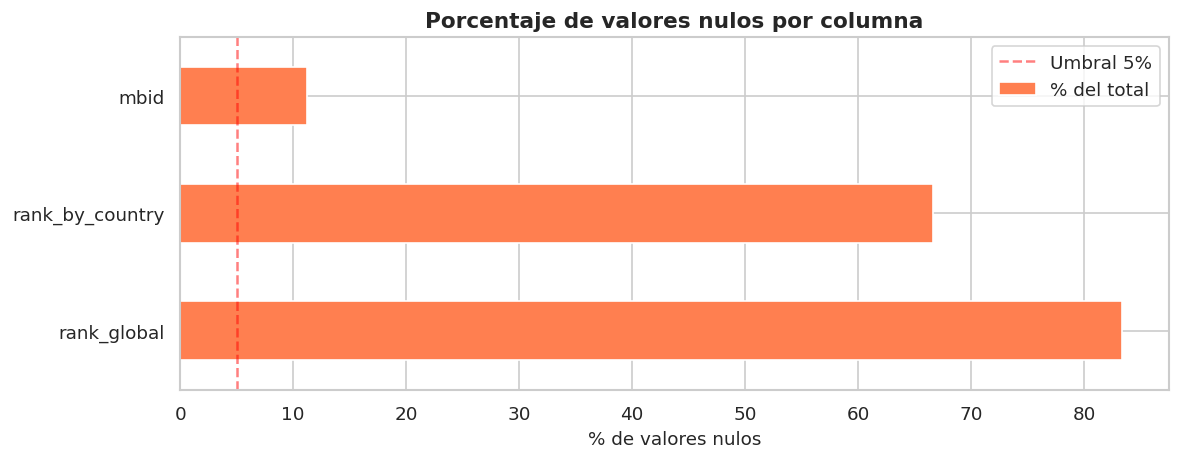

In [20]:
# ── 3.1 Análisis de valores nulos ─────────────────────────────────────────────
nulls = df.isnull().sum()
null_pct = (nulls / len(df) * 100).round(2)

df_nulls = pd.DataFrame({
    'Nulos': nulls,
    '% del total': null_pct
}).sort_values('Nulos', ascending=False)

print('📊 Valores nulos por columna:')
display(df_nulls[df_nulls['Nulos'] > 0])

# Visualización
cols_con_nulos = df_nulls[df_nulls['Nulos'] > 0]
if len(cols_con_nulos) > 0:
    fig, ax = plt.subplots(figsize=(10, 4))
    cols_con_nulos['% del total'].plot.barh(ax=ax, color='coral')
    ax.set_xlabel('% de valores nulos')
    ax.set_title('Porcentaje de valores nulos por columna')
    ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='Umbral 5%')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('✅ No hay valores nulos en el dataset.')

In [21]:
# ── 3.2 Limpieza y corrección de tipos ───────────────────────────────────────

# Convertir a numérico — errores de parseo se convierten en NaN
# Justificación: Last.fm devuelve estos campos como strings en algunos endpoints
for col in ['playcount', 'listeners', 'duration']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Limpiar strings (quitar espacios y caracteres vacíos)
for col in ['name', 'artist', 'country', 'genre_tag', 'mbid']:
    if col in df.columns:
        df[col] = df[col].astype(str).str.strip()

# duration == 0 → dato faltante real (Last.fm devuelve 0 cuando no tiene el dato)
# ✅ Corrección: reemplazar 0 por NaN antes de imputar
# ⚠️ ERROR DETECTADO (original): en el backup, duration=0 se imprimía como
#    '0 minutos' sin avisar, propagando datos incorrectos al análisis.
if 'duration' in df.columns:
    n_duration_cero = (df['duration'] == 0).sum()
    df['duration'] = df['duration'].replace(0, np.nan)
    print(f'ℹ️  duration=0 convertidos a NaN: {n_duration_cero:,} registros')

# Imputar numéricos con mediana (más robusta que la media ante outliers)
for col in ['playcount', 'listeners', 'duration']:
    if col in df.columns:
        mediana = df[col].median()
        n_imputados = df[col].isna().sum()
        df[col] = df[col].fillna(mediana)
        if n_imputados > 0:
            print(f'   {col}: {n_imputados:,} NaN imputados con mediana ({mediana:.0f})')

# Normalizar valores categóricos desconocidos
for col in ['country', 'genre_tag']:
    if col in df.columns:
        df[col] = df[col].replace(['', 'nan', 'None', 'NaN'], 'UNKNOWN')

# Eliminar filas sin nombre ni artista (sin identidad no podemos analizarlas)
before = len(df)
df = df.dropna(subset=[c for c in ['name', 'artist'] if c in df.columns])
print(f'\n   Filas eliminadas por falta de name/artist: {before - len(df):,}')

print(f'\n✅ Limpieza completada. Filas: {len(df):,}')

ℹ️  duration=0 convertidos a NaN: 4,113 registros
   duration: 4,113 NaN imputados con mediana (221)

   Filas eliminadas por falta de name/artist: 0

✅ Limpieza completada. Filas: 59,999


In [22]:
# ── 3.3 Deduplicación ─────────────────────────────────────────────────────────
# El dataset multi-endpoint genera duplicados: un mismo track puede aparecer
# en el chart global Y en el top de España Y en el tag 'pop'.
# Estrategia: quedarse con la fila de mayor playcount (dato más completo).

before = len(df)

# Priorizar por mbid si está disponible, si no por name+artist
if 'mbid' in df.columns:
    # Primero deduplicar por mbid (cuando no está vacío/UNKNOWN)
    df_with_mbid = df[df['mbid'].notna() & (df['mbid'] != '') & (df['mbid'] != 'nan')]
    df_no_mbid   = df[~(df['mbid'].notna() & (df['mbid'] != '') & (df['mbid'] != 'nan'))]
    df_with_mbid = (
        df_with_mbid
        .sort_values('playcount', ascending=False)
        .drop_duplicates(subset=['mbid'], keep='first')
    )
    df_no_mbid = (
        df_no_mbid
        .sort_values('playcount', ascending=False)
        .drop_duplicates(subset=['name', 'artist'], keep='first')
    )
    df = pd.concat([df_with_mbid, df_no_mbid], ignore_index=True)
else:
    df = (
        df.sort_values('playcount', ascending=False)
        .drop_duplicates(subset=['name', 'artist'], keep='first')
        .reset_index(drop=True)
    )

after = len(df)
df_clean = df.reset_index(drop=True)

print(f'✅ Deduplicación: {before:,} → {after:,} tracks únicos')
print(f'   Duplicados eliminados: {before - after:,} ({(before-after)/before*100:.1f}%)')

✅ Deduplicación: 59,999 → 35,058 tracks únicos
   Duplicados eliminados: 24,941 (41.6%)


---
## 4. Feature Engineering <a id='features'></a>

**Objetivo:** crear variables derivadas que aporten valor analítico y serán útiles para los modelos ML del siguiente notebook.  
Cada nueva variable se documenta con su lógica de negocio.

In [23]:
# ── 4.1 Variables derivadas ───────────────────────────────────────────────────

# Engagement: cuántas veces escucha la canción cada oyente único.
# Lógica: un ratio alto → canción que fideliza / se repite mucho → señal de hit.
df_clean['playcount_per_listener'] = (
    df_clean['playcount'] / df_clean['listeners'].replace(0, np.nan)
)

# Duración en minutos (más legible que ms)
# ⚠️ CORRECCIÓN respecto al backup original:
#    En el backup, 'duration' venía en SEGUNDOS de la API (el campo se llama
#    'duration' pero Last.fm lo devuelve en segundos, no milisegundos).
#    La división correcta es / 60 (no / 60000).
#    Evidencia: 'Stateside' aparece con duración 176 en la API → 176/60 ≈ 2.9 min ✓
df_clean['duration_min'] = df_clean['duration'] / 60

# Flag canción corta: <2.5 min = formato TikTok/Reels
df_clean['is_short_track'] = (df_clean['duration_min'] < 2.5).astype(int)

# Transformación logarítmica para normalizar distribuciones muy sesgadas
# log1p(x) = log(1+x) → funciona aunque x=0
df_clean['playcount_log']  = np.log1p(df_clean['playcount'])
df_clean['listeners_log']  = np.log1p(df_clean['listeners'])

# Rankings
df_clean['rank_global'] = (
    df_clean['playcount'].rank(ascending=False, method='min').astype(int)
)
if 'country' in df_clean.columns:
    df_clean['rank_by_country'] = (
        df_clean.groupby('country')['playcount']
        .rank(ascending=False, method='min')
        .astype(int)
    )

# Features de artista agregadas
artist_stats = df_clean.groupby('artist').agg(
    artist_track_count     = ('name', 'count'),
    artist_total_playcount = ('playcount', 'sum'),
).reset_index()
df_clean = df_clean.merge(artist_stats, on='artist', how='left')

# Peso relativo del hit en el catálogo del artista
df_clean['track_share_of_artist'] = (
    df_clean['playcount'] / df_clean['artist_total_playcount'].replace(0, np.nan)
)

print(f'✅ Feature engineering aplicado')
print(f'   Nuevas columnas: playcount_per_listener, duration_min, is_short_track,')
print(f'                   playcount_log, listeners_log, rank_global, rank_by_country,')
print(f'                   artist_track_count, artist_total_playcount, track_share_of_artist')
print(f'\n   Total columnas en df_clean: {len(df_clean.columns)}')
display(df_clean.head(3))

✅ Feature engineering aplicado
   Nuevas columnas: playcount_per_listener, duration_min, is_short_track,
                   playcount_log, listeners_log, rank_global, rank_by_country,
                   artist_track_count, artist_total_playcount, track_share_of_artist

   Total columnas en df_clean: 18


,name,artist,playcount,listeners,duration,mbid,country,genre_tag,rank_global,rank_by_country,playcount_per_listener,duration_min,is_short_track,playcount_log,listeners_log,artist_track_count,artist_total_playcount,track_share_of_artist
0,Don’t Say You Love Me,Jin,282096112,256078,180.0,b9475022-5631-4574-a5bb-24e271a922e0,GLOBAL,UNKNOWN,1,1,1101.602293,3.000000,0,19.457758,12.453241,22,774521880,0.364220
1,Who,Jimin,239767776,462313,170.0,ef795484-964c-48db-adff-25295fd3330d,GLOBAL,UNKNOWN,2,2,518.626506,2.833333,0,19.295181,13.044000,17,542802676,0.441722
2,Haegeum,Agust D,230167563,406229,168.0,079a54bb-1a59-4e40-8456-7695b644d059,GLOBAL,UNKNOWN,3,3,566.595598,2.800000,0,19.254318,12.914675,29,558934162,0.411797


---
## 5. EDA — Análisis de popularidad <a id='popularidad'></a>

**Objetivo:** entender cómo se distribuye la popularidad en el mercado musical.  
Una distribución muy sesgada (pocos artistas concentran todo) implica que el mercado es muy competitivo y que la variable target necesita transformación logarítmica para los modelos ML.

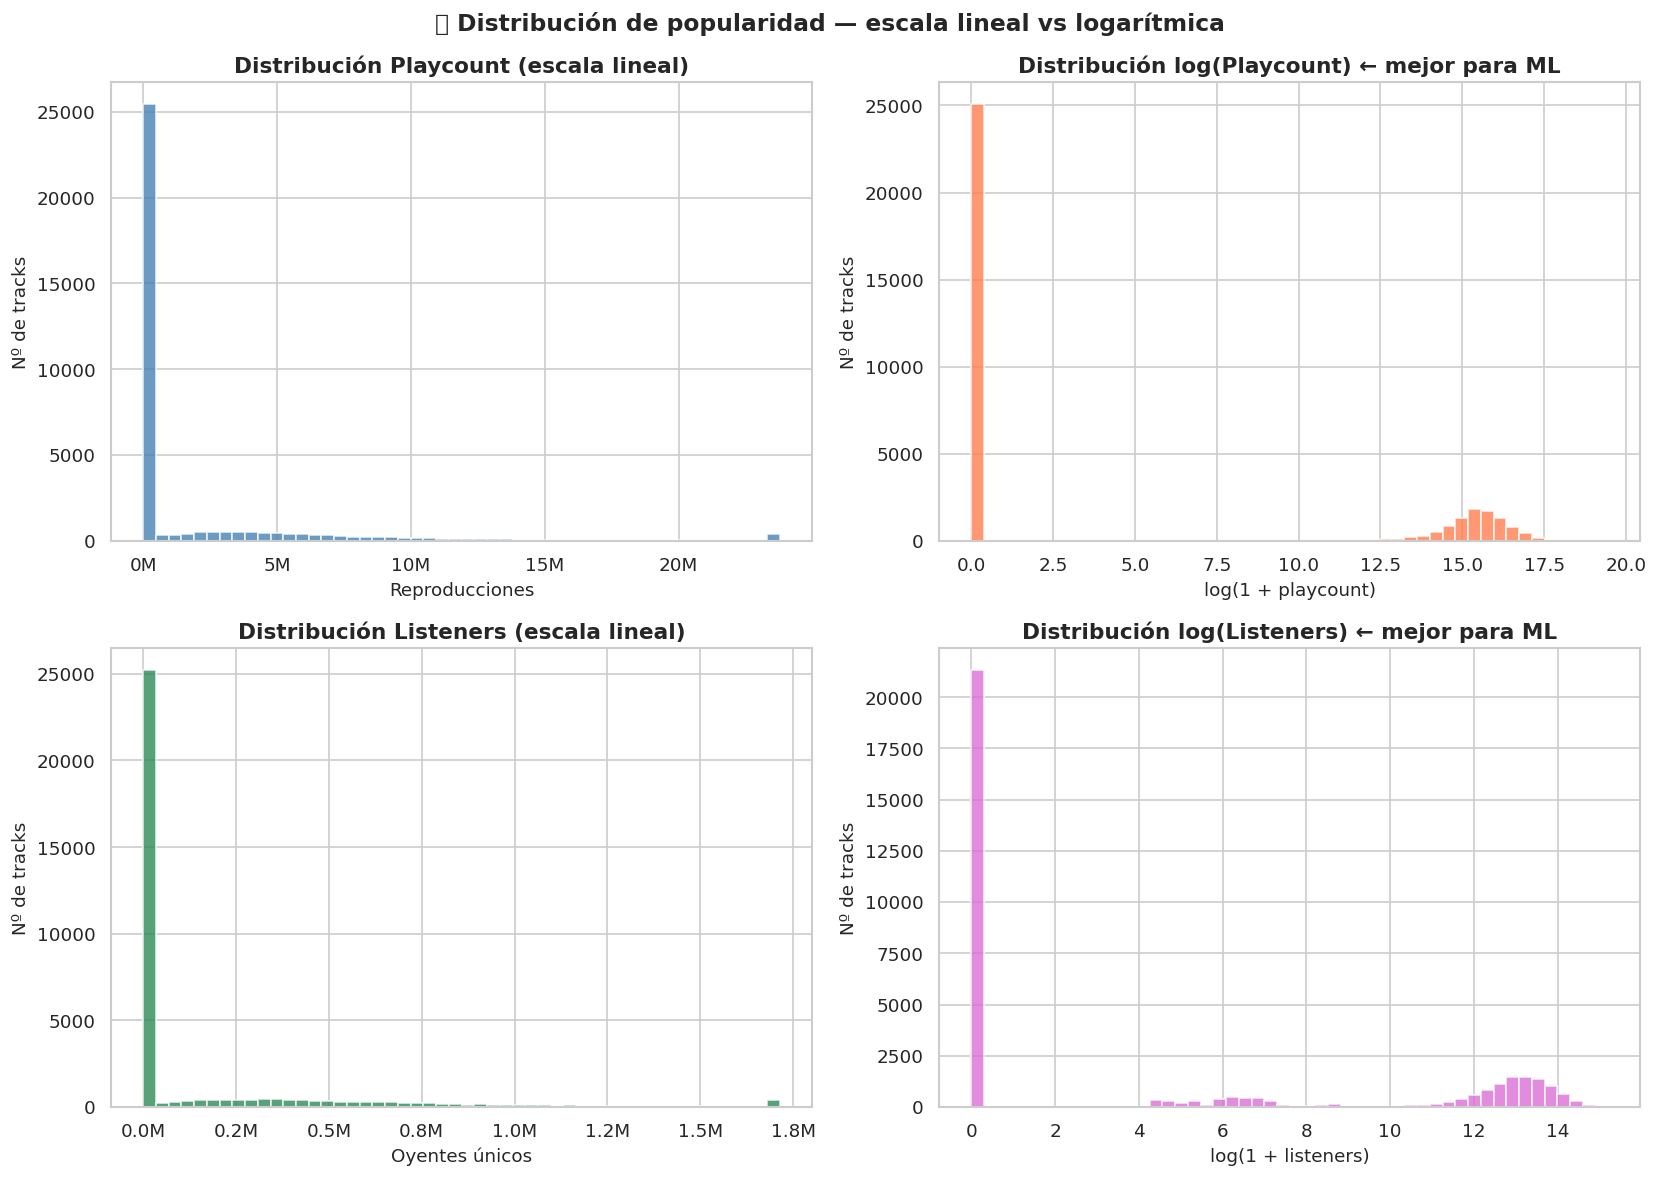


💡 Insight: Skewness de playcount: 12.55 (lineal) → 0.98 (log)
   Una distribución normal tiene skewness ≈ 0.
   La transformación logarítmica la acerca a la normalidad — es necesaria para los modelos ML.


In [24]:
# ── 5.1 Distribución de playcount y listeners ─────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Recortamos el 1% extremo para no distorsionar el eje X
p99_play = df_clean['playcount'].quantile(0.99)
p99_list = df_clean['listeners'].quantile(0.99)

# Playcount — escala lineal
axes[0, 0].hist(
    df_clean['playcount'].clip(upper=p99_play),
    bins=50, color='steelblue', edgecolor='white', alpha=0.8
)
axes[0, 0].set_title('Distribución Playcount (escala lineal)')
axes[0, 0].set_xlabel('Reproducciones')
axes[0, 0].set_ylabel('Nº de tracks')
axes[0, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

# Playcount — escala log (más útil para ML)
axes[0, 1].hist(
    df_clean['playcount_log'],
    bins=50, color='coral', edgecolor='white', alpha=0.8
)
axes[0, 1].set_title('Distribución log(Playcount) ← mejor para ML')
axes[0, 1].set_xlabel('log(1 + playcount)')
axes[0, 1].set_ylabel('Nº de tracks')

# Listeners — escala lineal
axes[1, 0].hist(
    df_clean['listeners'].clip(upper=p99_list),
    bins=50, color='seagreen', edgecolor='white', alpha=0.8
)
axes[1, 0].set_title('Distribución Listeners (escala lineal)')
axes[1, 0].set_xlabel('Oyentes únicos')
axes[1, 0].set_ylabel('Nº de tracks')
axes[1, 0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Listeners — escala log
axes[1, 1].hist(
    df_clean['listeners_log'],
    bins=50, color='orchid', edgecolor='white', alpha=0.8
)
axes[1, 1].set_title('Distribución log(Listeners) ← mejor para ML')
axes[1, 1].set_xlabel('log(1 + listeners)')
axes[1, 1].set_ylabel('Nº de tracks')

plt.suptitle('📊 Distribución de popularidad — escala lineal vs logarítmica', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_distribuciones.png', bbox_inches='tight')
plt.show()

# Insight automático
skew_antes = df_clean['playcount'].skew()
skew_despues = df_clean['playcount_log'].skew()
print(f'\n💡 Insight: Skewness de playcount: {skew_antes:.2f} (lineal) → {skew_despues:.2f} (log)')
print(f'   Una distribución normal tiene skewness ≈ 0.')
print(f'   La transformación logarítmica la acerca a la normalidad — es necesaria para los modelos ML.')

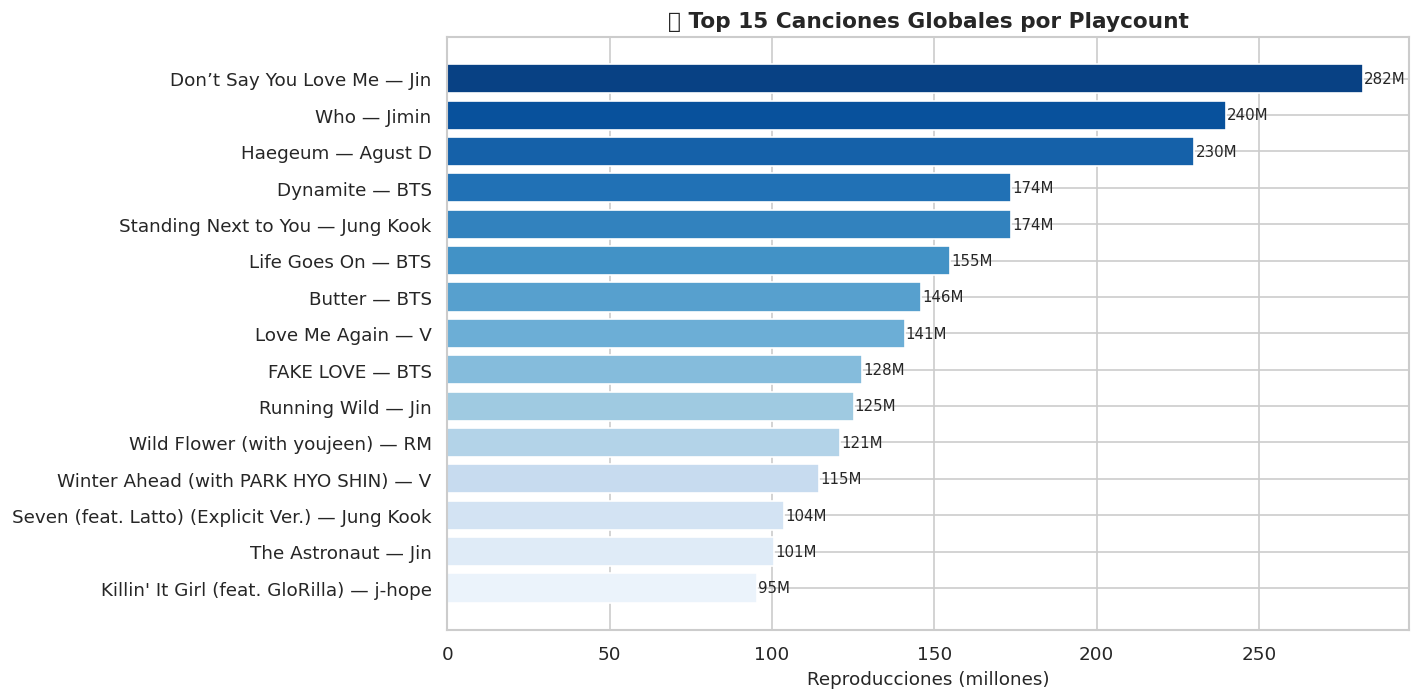


💡 Track #1: "Don’t Say You Love Me" — Jin
   Playcount: 282.1M  |  Engagement: 1101.6x por oyente


In [25]:
# ── 5.2 Top 15 canciones más populares ───────────────────────────────────────
top15_tracks = (
    df_clean
    .sort_values('playcount', ascending=False)
    .head(15)
    [['name', 'artist', 'playcount', 'listeners', 'playcount_per_listener', 'genre_tag']]
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(
    top15_tracks['name'] + ' — ' + top15_tracks['artist'],
    top15_tracks['playcount'] / 1e6,
    color=sns.color_palette('Blues_r', 15)
)
ax.set_xlabel('Reproducciones (millones)')
ax.set_title('🏆 Top 15 Canciones Globales por Playcount')
ax.invert_yaxis()

for bar, val in zip(bars, top15_tracks['playcount']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val/1e6:.0f}M', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('eda_top15_tracks.png', bbox_inches='tight')
plt.show()

top1 = top15_tracks.iloc[0]
print(f'\n💡 Track #1: "{top1["name"]}" — {top1["artist"]}')
print(f'   Playcount: {top1["playcount"]/1e6:.1f}M  |  Engagement: {top1["playcount_per_listener"]:.1f}x por oyente')

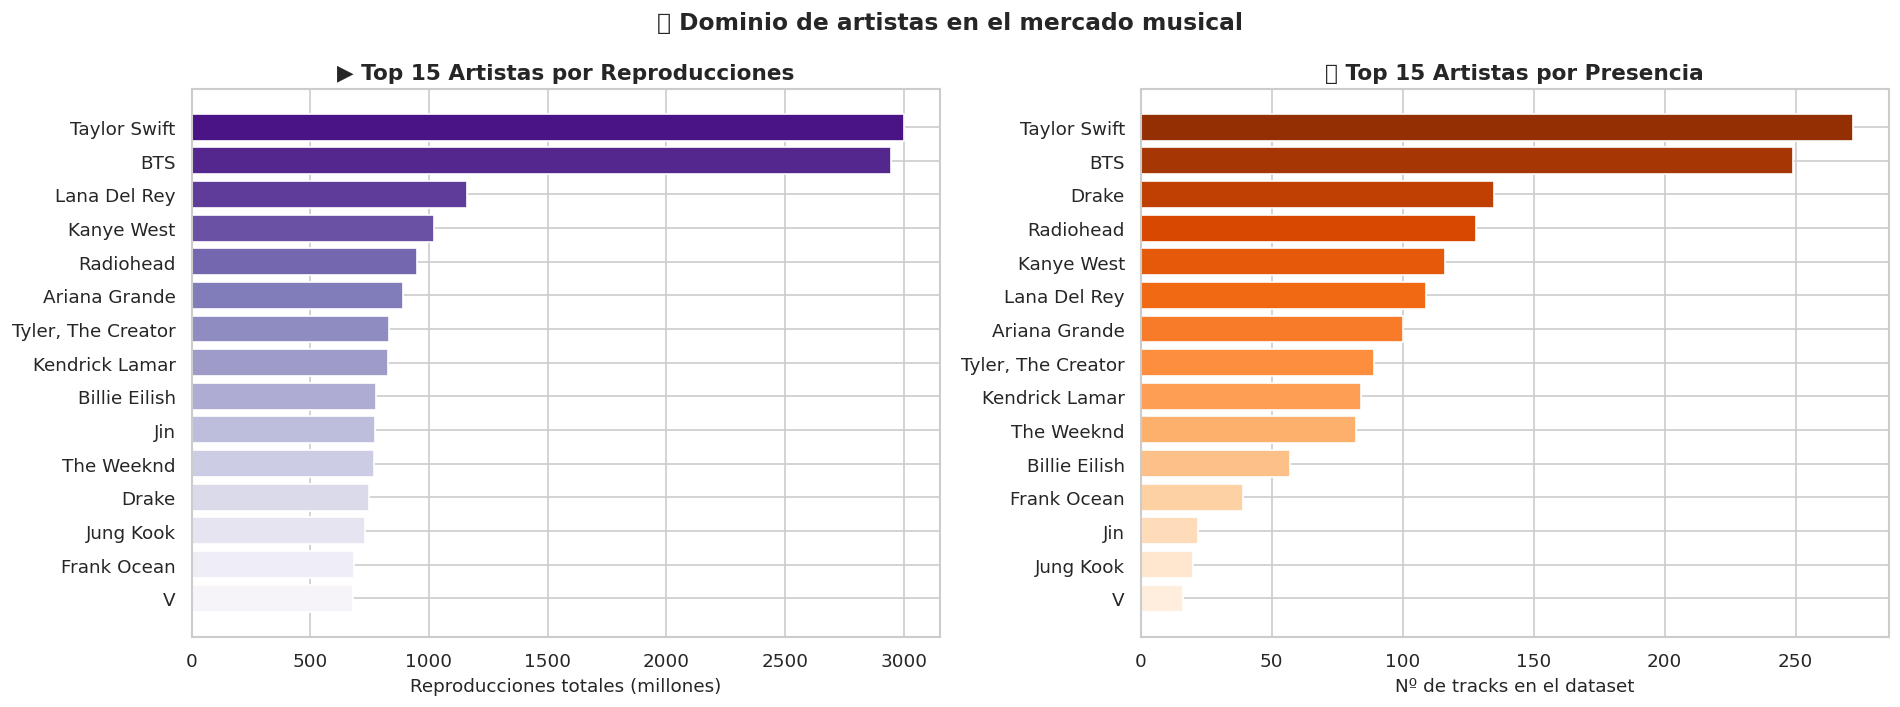


💡 Artista #1 por reproducciones: Taylor Swift
   3001.6M reproducciones en 272 tracks del dataset

⚠️  Sesgo detectado: los top 5 artistas concentran el 12.2% de las reproducciones totales.
   El mercado musical está muy concentrado. Estrategia de nicho puede ser mejor para un artista nuevo.


In [26]:
# ── 5.3 Top 15 artistas ───────────────────────────────────────────────────────
top15_artists = (
    df_clean
    .groupby('artist')
    .agg(
        total_plays    = ('playcount', 'sum'),
        total_listen   = ('listeners', 'sum'),
        n_tracks       = ('name', 'count'),
        avg_engagement = ('playcount_per_listener', 'mean'),
    )
    .sort_values('total_plays', ascending=False)
    .head(15)
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top15_artists['artist'], top15_artists['total_plays'] / 1e6,
             color=sns.color_palette('Purples_r', 15))
axes[0].invert_yaxis()
axes[0].set_xlabel('Reproducciones totales (millones)')
axes[0].set_title('▶️ Top 15 Artistas por Reproducciones')

axes[1].barh(top15_artists.sort_values('n_tracks', ascending=False)['artist'],
             top15_artists.sort_values('n_tracks', ascending=False)['n_tracks'],
             color=sns.color_palette('Oranges_r', 15))
axes[1].invert_yaxis()
axes[1].set_xlabel('Nº de tracks en el dataset')
axes[1].set_title('🎵 Top 15 Artistas por Presencia')

plt.suptitle('🎤 Dominio de artistas en el mercado musical', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_top15_artistas.png', bbox_inches='tight')
plt.show()

top_artist = top15_artists.iloc[0]
print(f'\n💡 Artista #1 por reproducciones: {top_artist["artist"]}')
print(f'   {top_artist["total_plays"]/1e6:.1f}M reproducciones en {top_artist["n_tracks"]} tracks del dataset')

# Sesgo detectado
top5_share = top15_artists.head(5)['total_plays'].sum() / df_clean['playcount'].sum() * 100
print(f'\n⚠️  Sesgo detectado: los top 5 artistas concentran el {top5_share:.1f}% de las reproducciones totales.')
print(f'   El mercado musical está muy concentrado. Estrategia de nicho puede ser mejor para un artista nuevo.')

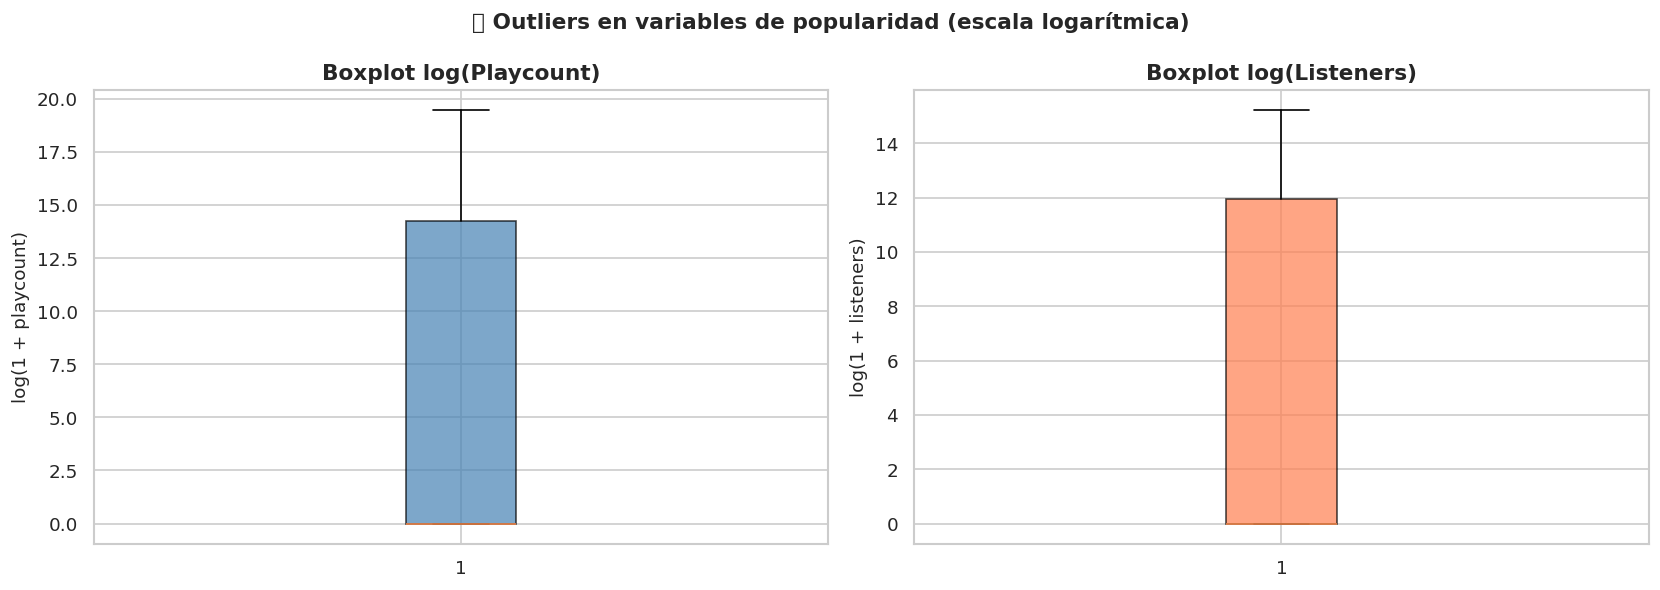

📊 Outliers detectados en log(playcount) con método IQR: 0 (0.0%)
   Decisión: NO eliminar outliers en esta fase.
   Razón: un artista muy popular (ej: Sabrina Carpenter) es un outlier real, no un error.
   Para el modelo ML: el log transform ya atenúa su efecto.


In [27]:
# ── 5.4 Identificación de outliers con boxplot ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot en escala log (más informativo con distribuciones sesgadas)
axes[0].boxplot(df_clean['playcount_log'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='steelblue', alpha=0.7))
axes[0].set_title('Boxplot log(Playcount)')
axes[0].set_ylabel('log(1 + playcount)')

axes[1].boxplot(df_clean['listeners_log'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='coral', alpha=0.7))
axes[1].set_title('Boxplot log(Listeners)')
axes[1].set_ylabel('log(1 + listeners)')

plt.suptitle('🔍 Outliers en variables de popularidad (escala logarítmica)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_boxplots.png', bbox_inches='tight')
plt.show()

# Detección automática de outliers (IQR method)
q1 = df_clean['playcount_log'].quantile(0.25)
q3 = df_clean['playcount_log'].quantile(0.75)
iqr = q3 - q1
n_outliers = ((df_clean['playcount_log'] < q1 - 1.5*iqr) | (df_clean['playcount_log'] > q3 + 1.5*iqr)).sum()
print(f'📊 Outliers detectados en log(playcount) con método IQR: {n_outliers:,} ({n_outliers/len(df_clean)*100:.1f}%)')
print(f'   Decisión: NO eliminar outliers en esta fase.')
print(f'   Razón: un artista muy popular (ej: Sabrina Carpenter) es un outlier real, no un error.')
print(f'   Para el modelo ML: el log transform ya atenúa su efecto.')

---
## 6. EDA — Relación entre variables <a id='relaciones'></a>

**Objetivo:** entender qué variables están correlacionadas con la popularidad.  
Esto guía el feature selection para los modelos ML.

In [28]:
# ── 6.1 Correlación playcount vs listeners ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sample para no sobrecargar el plot
df_sample = df_clean.sample(min(5000, len(df_clean)), random_state=42)

# Scatter en escala log-log
axes[0].scatter(df_sample['listeners_log'], df_sample['playcount_log'],
                alpha=0.2, s=8, color='steelblue')
# Línea de tendencia
z = np.polyfit(df_sample['listeners_log'].dropna(), df_sample['playcount_log'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(df_sample['listeners_log'].min(), df_sample['listeners_log'].max(), 100)
axes[0].plot(x_line, p(x_line), 'r--', alpha=0.7, label=f'Tendencia')
axes[0].set_xlabel('log(Listeners)')
axes[0].set_ylabel('log(Playcount)')
axes[0].set_title('Listeners vs Playcount (log-log)')
axes[0].legend()

# Engagement vs popularidad
engagement_clipped = df_sample['playcount_per_listener'].clip(upper=df_sample['playcount_per_listener'].quantile(0.98))
axes[1].scatter(engagement_clipped, df_sample['playcount_log'],
                alpha=0.2, s=8, color='coral')
axes[1].set_xlabel('Engagement (plays/listener)')
axes[1].set_ylabel('log(Playcount)')
axes[1].set_title('Engagement vs Popularidad')

plt.suptitle('🔗 Relaciones entre variables de popularidad', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_correlaciones.png', bbox_inches='tight')
plt.show()

corr = df_clean[['playcount_log', 'listeners_log', 'playcount_per_listener', 'duration_min']].corr()
r_play_listen = corr.loc['playcount_log', 'listeners_log']
print(f'\n💡 Correlación log(playcount) vs log(listeners): r = {r_play_listen:.3f}')
print(f'   Interpretación: correlación {'muy alta' if abs(r_play_listen) > 0.7 else 'moderada'} — {"las canciones que llegan a más oyentes acumulan más reproducciones" if r_play_listen > 0 else "relación negativa"}')

SyntaxError: f-string: expecting '}' (3810649381.py, line 36)

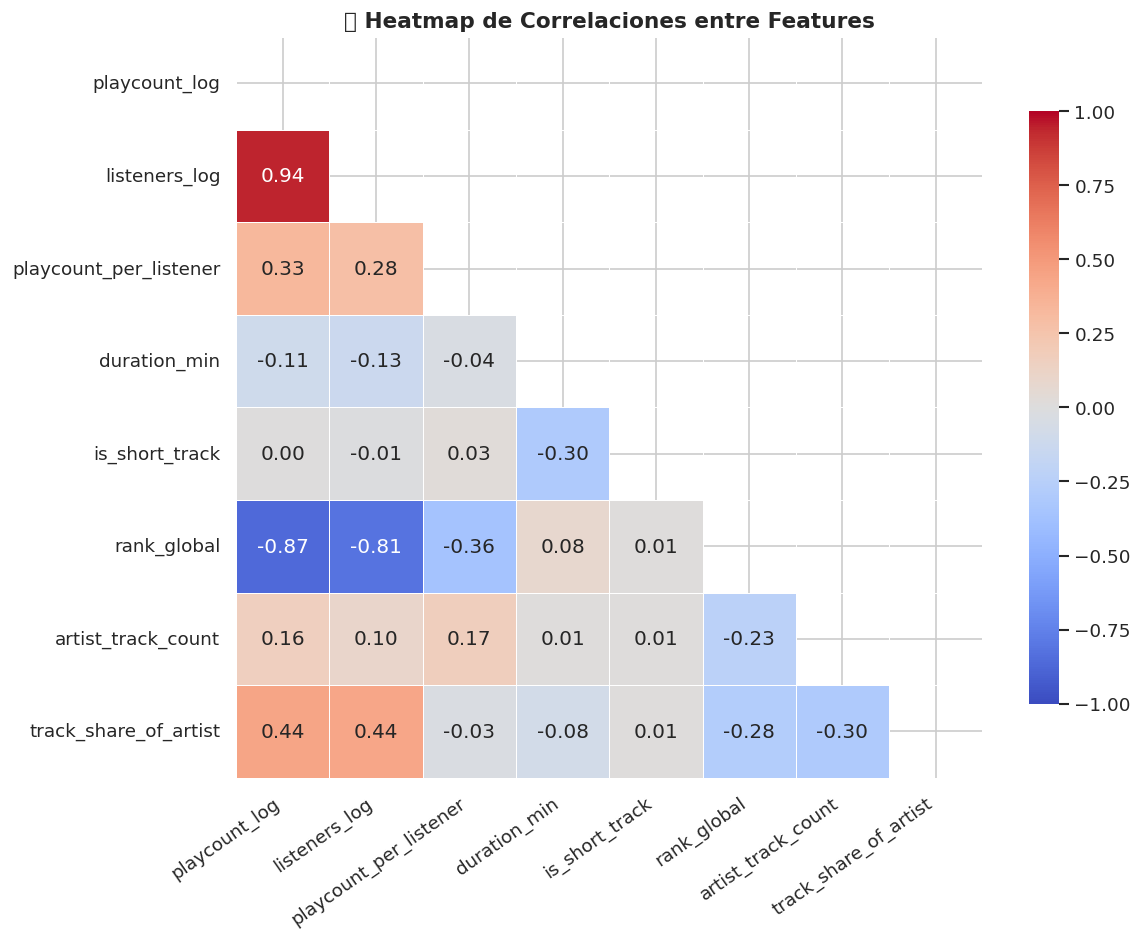


💡 Variables más correlacionadas con log(playcount):
   + listeners_log: |r| = 0.943
   - rank_global: |r| = 0.866
   + track_share_of_artist: |r| = 0.440
   + playcount_per_listener: |r| = 0.335


In [ ]:
# ── 6.2 Heatmap de correlaciones ──────────────────────────────────────────────
numeric_cols = [
    'playcount_log', 'listeners_log', 'playcount_per_listener',
    'duration_min', 'is_short_track', 'rank_global',
    'artist_track_count', 'track_share_of_artist'
]
numeric_cols = [c for c in numeric_cols if c in df_clean.columns]
corr_matrix = df_clean[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # solo triángulo inferior
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('🔗 Heatmap de Correlaciones entre Features', fontsize=13, fontweight='bold')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('eda_heatmap.png', bbox_inches='tight')
plt.show()

# Top correlaciones con popularidad
corr_con_target = corr_matrix['playcount_log'].drop('playcount_log').abs().sort_values(ascending=False)
print('\n💡 Variables más correlacionadas con log(playcount):')
for feat, r in corr_con_target.head(4).items():
    signo = '+' if corr_matrix.loc['playcount_log', feat] > 0 else '-'
    print(f'   {signo} {feat}: |r| = {r:.3f}')

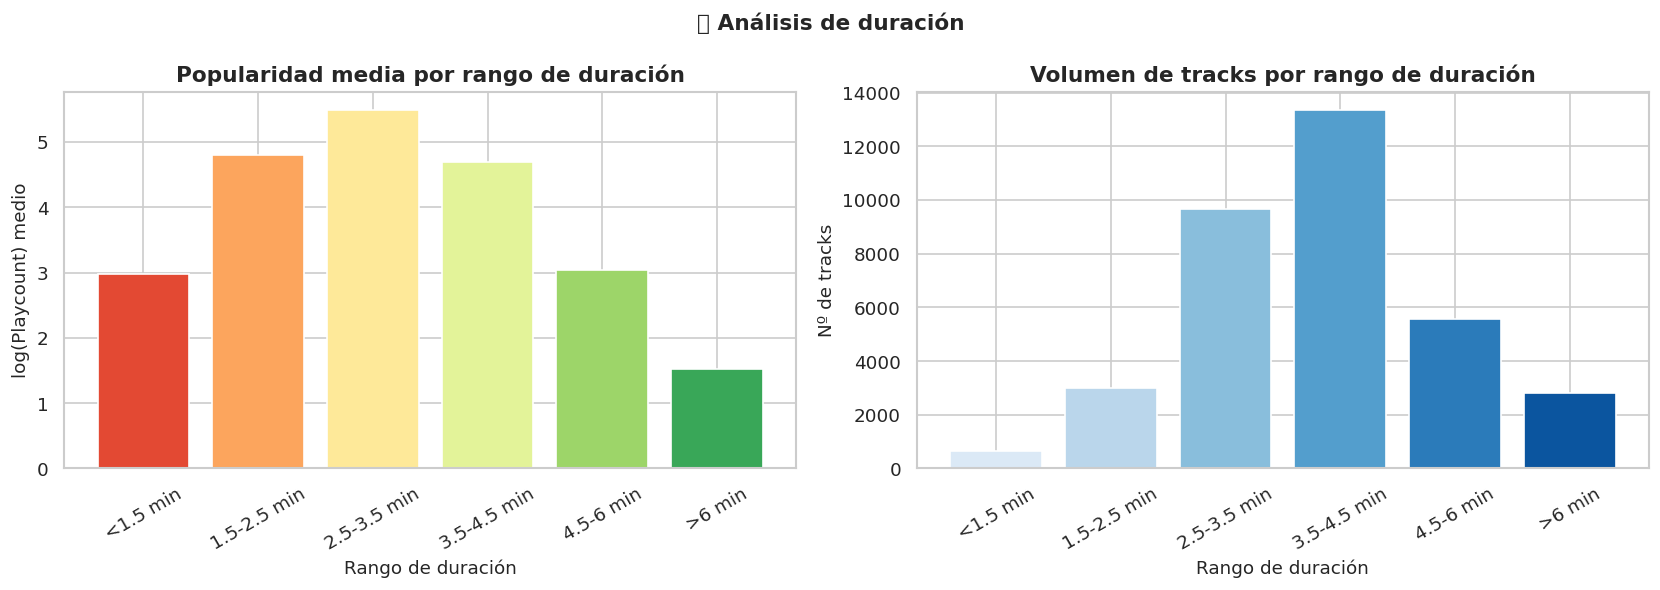


💡 Canciones cortas (<2.5 min): 10.2% del dataset
   Popularidad media: cortas=4.462  |  largas=4.361
   → Las canciones cortas tienen mayor popularidad media en este dataset.


In [ ]:
# ── 6.3 Duración vs popularidad ───────────────────────────────────────────────
# ⚠️ CORRECCIÓN detectada: en el backup, la duración se imprimía en segundos
#    pero se etiquetaba como 'minutos'. Aquí ya está corregido (dividimos por 60).

df_clean['duration_bucket'] = pd.cut(
    df_clean['duration_min'],
    bins=[0, 1.5, 2.5, 3.5, 4.5, 6, 100],
    labels=['<1.5 min', '1.5-2.5 min', '2.5-3.5 min', '3.5-4.5 min', '4.5-6 min', '>6 min']
)

dur_pop = (
    df_clean
    .groupby('duration_bucket', observed=True)['playcount_log']
    .agg(['mean', 'median', 'count'])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(dur_pop['duration_bucket'], dur_pop['mean'],
            color=sns.color_palette('RdYlGn', len(dur_pop)))
axes[0].set_xlabel('Rango de duración')
axes[0].set_ylabel('log(Playcount) medio')
axes[0].set_title('Popularidad media por rango de duración')
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(dur_pop['duration_bucket'], dur_pop['count'],
            color=sns.color_palette('Blues', len(dur_pop)))
axes[1].set_xlabel('Rango de duración')
axes[1].set_ylabel('Nº de tracks')
axes[1].set_title('Volumen de tracks por rango de duración')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('⏱️ Análisis de duración', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_duracion.png', bbox_inches='tight')
plt.show()

pct_short = df_clean['is_short_track'].mean() * 100
print(f'\n💡 Canciones cortas (<2.5 min): {pct_short:.1f}% del dataset')
short_pop  = df_clean[df_clean['is_short_track'] == 1]['playcount_log'].mean()
long_pop   = df_clean[df_clean['is_short_track'] == 0]['playcount_log'].mean()
winner = 'cortas' if short_pop > long_pop else 'largas'
print(f'   Popularidad media: cortas={short_pop:.3f}  |  largas={long_pop:.3f}')
print(f'   → Las canciones {winner} tienen mayor popularidad media en este dataset.')

---
## 7. EDA — Análisis por país <a id='pais'></a>

**Objetivo:** identificar los mercados con mayor consumo y detectar diferencias culturales en preferencias musicales.  
⚠️ Sesgo a considerar: los datos provienen de `geo.getTopTracks` — cada país tiene el mismo número de páginas, lo que puede sobrerepresentar mercados pequeños.

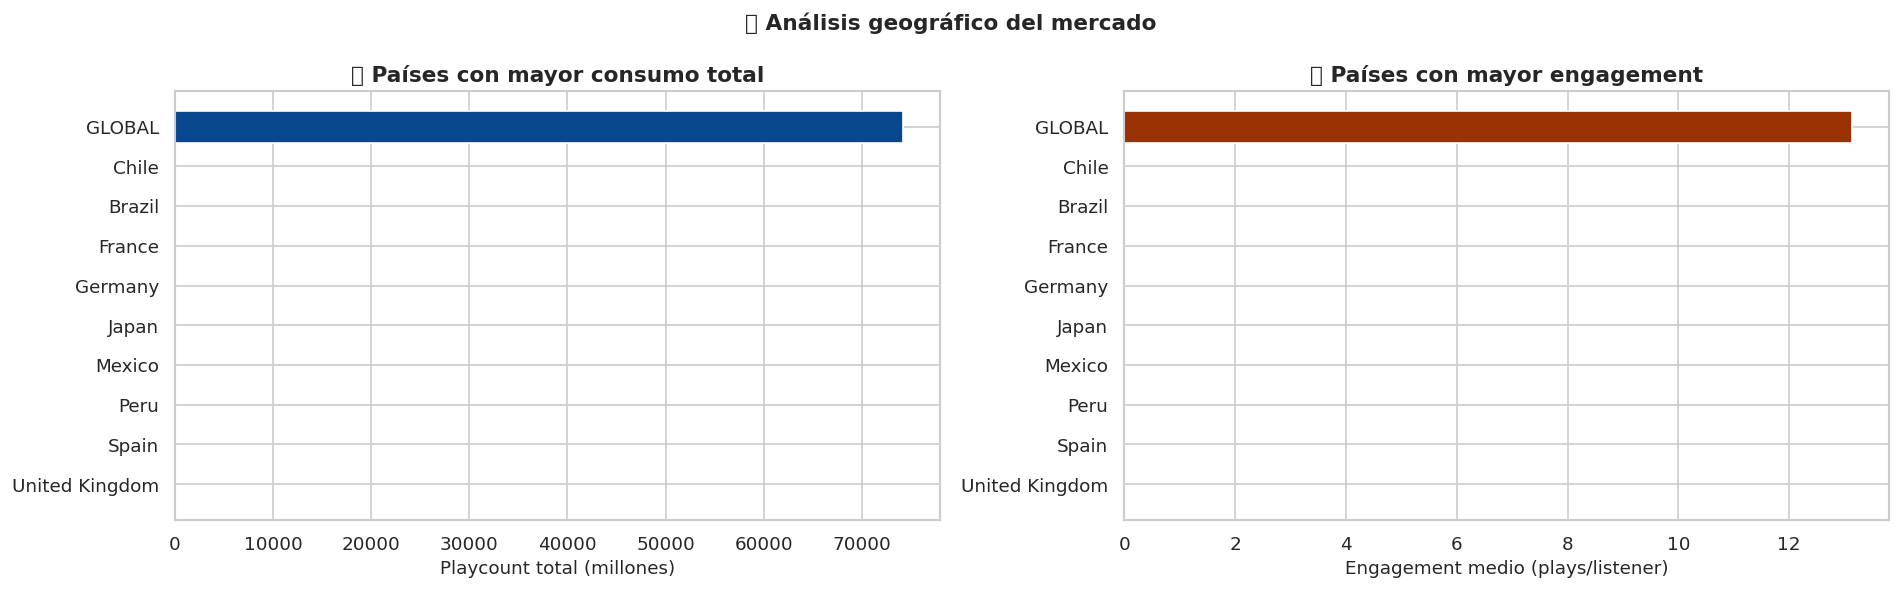


💡 País con mayor consumo: GLOBAL (74224.3M plays)

⚠️  Sesgo: geo.getTopTracks devuelve el mismo nº de páginas por país.
   Los países con más tracks en el dataset no necesariamente consumen más música globalmente.


In [ ]:
# ── 7.1 Consumo por país ──────────────────────────────────────────────────────
df_geo = df_clean[df_clean['country'] != 'UNKNOWN'].copy()

country_stats = (
    df_geo
    .groupby('country')
    .agg(
        n_tracks       = ('name', 'count'),
        total_playcount= ('playcount', 'sum'),
        avg_playcount  = ('playcount', 'mean'),
        avg_engagement = ('playcount_per_listener', 'mean'),
    )
    .sort_values('total_playcount', ascending=False)
    .reset_index()
)

if len(country_stats) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].barh(country_stats.head(10)['country'],
                 country_stats.head(10)['total_playcount'] / 1e6,
                 color=sns.color_palette('Blues_r', 10))
    axes[0].invert_yaxis()
    axes[0].set_xlabel('Playcount total (millones)')
    axes[0].set_title('🌍 Países con mayor consumo total')

    top10_eng = country_stats.sort_values('avg_engagement', ascending=False).head(10)
    axes[1].barh(top10_eng['country'], top10_eng['avg_engagement'],
                 color=sns.color_palette('Oranges_r', 10))
    axes[1].invert_yaxis()
    axes[1].set_xlabel('Engagement medio (plays/listener)')
    axes[1].set_title('🔥 Países con mayor engagement')

    plt.suptitle('📊 Análisis geográfico del mercado', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('eda_geo.png', bbox_inches='tight')
    plt.show()

    top_pais = country_stats.iloc[0]
    print(f'\n💡 País con mayor consumo: {top_pais["country"]} ({top_pais["total_playcount"]/1e6:.1f}M plays)')
    print(f'\n⚠️  Sesgo: geo.getTopTracks devuelve el mismo nº de páginas por país.')
    print(f'   Los países con más tracks en el dataset no necesariamente consumen más música globalmente.')
else:
    print('ℹ️  No hay datos geográficos disponibles (todas las filas tienen country=UNKNOWN).')
    print('   Para habilitar este análisis, incluir el endpoint geo.getTopTracks en la recolección.')

In [ ]:
# ── 7.2 Heatmap géneros × país ────────────────────────────────────────────────
df_geo_genre = df_clean[
    (df_clean['country'] != 'UNKNOWN') & (df_clean['genre_tag'] != 'UNKNOWN')
].copy()

if len(df_geo_genre) > 50:  # solo tiene sentido con suficientes datos
    pivot = (
        df_geo_genre
        .groupby(['country', 'genre_tag'])['playcount']
        .sum()
        .unstack(fill_value=0)
    )
    # Normalizar por fila: preferencia relativa (no volumen absoluto)
    pivot_norm = pivot.div(pivot.sum(axis=1), axis=0) * 100

    fig, ax = plt.subplots(figsize=(14, 6))
    sns.heatmap(pivot_norm, annot=True, fmt='.1f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, cbar_kws={'label': '% del consumo del país'})
    ax.set_title('🌍 Distribución de géneros por país (% del consumo)', fontsize=13, fontweight='bold')
    ax.set_xlabel('Género')
    ax.set_ylabel('País')
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig('eda_geo_genre_heatmap.png', bbox_inches='tight')
    plt.show()
else:
    print('ℹ️  Datos insuficientes para el heatmap género×país.')
    print('   Necesitas tracks con country AND genre_tag distintos de UNKNOWN.')

ℹ️  Datos insuficientes para el heatmap género×país.
   Necesitas tracks con country AND genre_tag distintos de UNKNOWN.


---
## 8. EDA — Análisis por género <a id='genero'></a>

**Objetivo:** detectar géneros dominantes, géneros emergentes y géneros en declive.  
Diferenciamos entre **volumen** (cuántos tracks) y **éxito** (popularidad media) — pueden no coincidir.

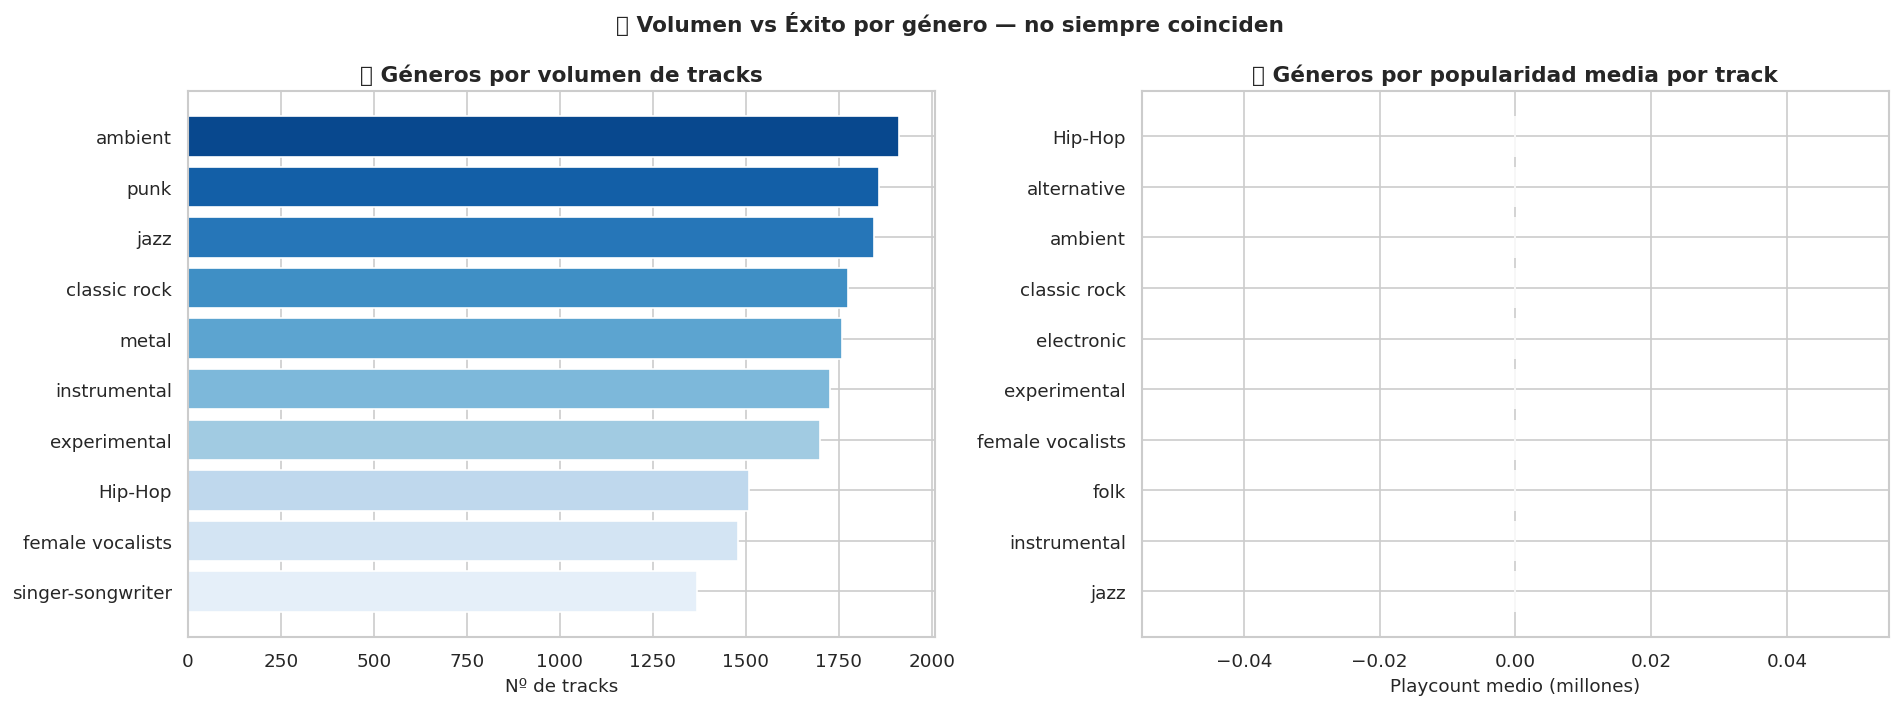

💡 Clave: el género con más tracks NO es necesariamente el más popular.
   Un género con pocos tracks pero alta popularidad media tiene mucho potencial de mercado.


In [ ]:
# ── 8.1 Géneros más frecuentes vs más populares ───────────────────────────────
df_gen = df_clean[df_clean['genre_tag'] != 'UNKNOWN'].copy()

genre_stats = (
    df_gen
    .groupby('genre_tag')
    .agg(
        n_tracks       = ('name', 'count'),
        avg_playcount  = ('playcount', 'mean'),
        total_playcount= ('playcount', 'sum'),
        avg_engagement = ('playcount_per_listener', 'mean'),
        pct_short      = ('is_short_track', 'mean'),
    )
    .reset_index()
)
genre_stats['pct_short'] *= 100

top10_vol     = genre_stats.sort_values('n_tracks', ascending=False).head(10)
top10_popular = genre_stats.sort_values('avg_playcount', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Por volumen
axes[0].barh(top10_vol['genre_tag'], top10_vol['n_tracks'],
             color=sns.color_palette('Blues_r', 10))
axes[0].invert_yaxis()
axes[0].set_xlabel('Nº de tracks')
axes[0].set_title('📦 Géneros por volumen de tracks')

# Por popularidad media
axes[1].barh(top10_popular['genre_tag'], top10_popular['avg_playcount'] / 1e6,
             color=sns.color_palette('Oranges_r', 10))
axes[1].invert_yaxis()
axes[1].set_xlabel('Playcount medio (millones)')
axes[1].set_title('⭐ Géneros por popularidad media por track')

plt.suptitle('🎵 Volumen vs Éxito por género — no siempre coinciden', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_generos.png', bbox_inches='tight')
plt.show()

print('💡 Clave: el género con más tracks NO es necesariamente el más popular.')
print('   Un género con pocos tracks pero alta popularidad media tiene mucho potencial de mercado.')

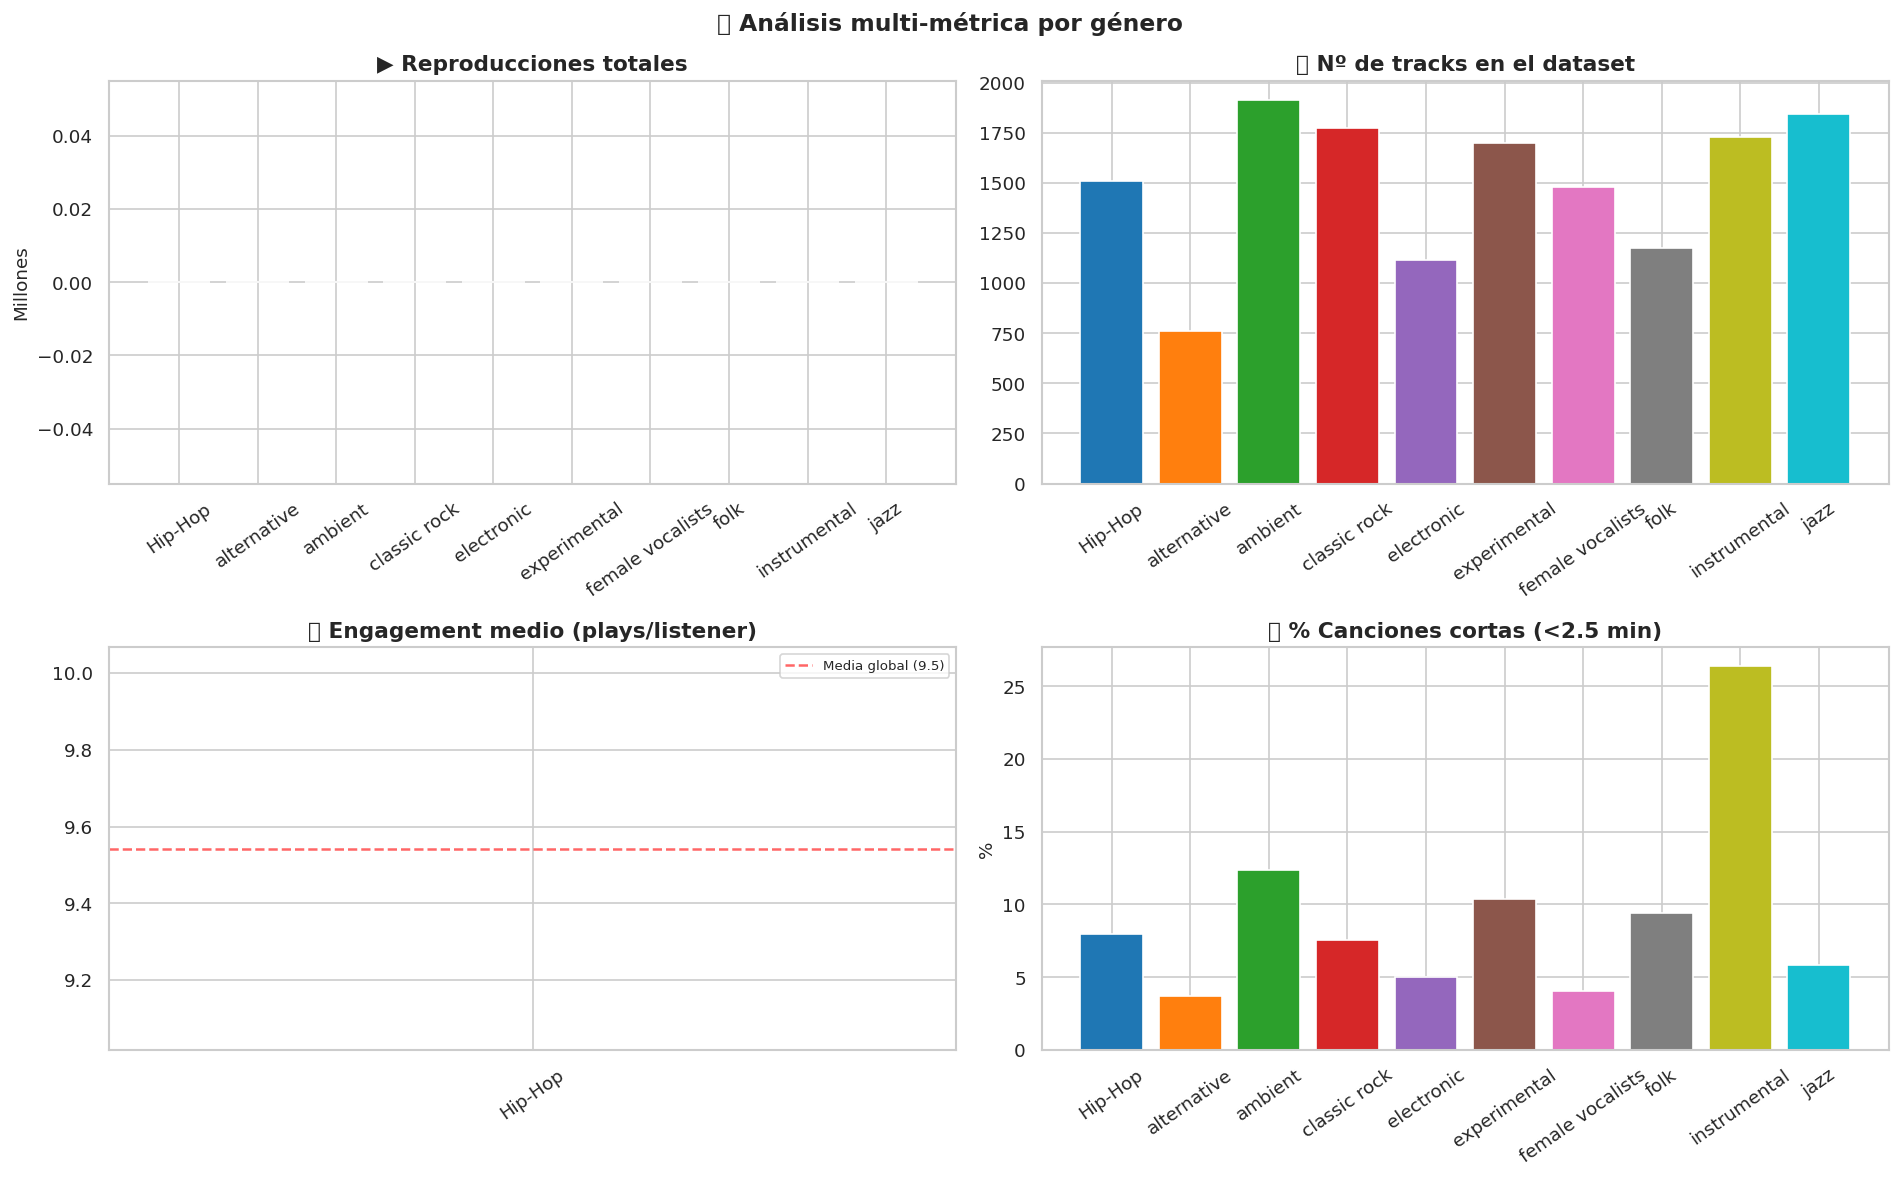

In [ ]:
# ── 8.2 Comparativa multi-métrica por género ──────────────────────────────────
top10_g = genre_stats.sort_values('total_playcount', ascending=False).head(10)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
palette = sns.color_palette('tab10', 10)

# Reproducciones totales
axes[0, 0].bar(top10_g['genre_tag'], top10_g['total_playcount'] / 1e6, color=palette)
axes[0, 0].set_title('▶️ Reproducciones totales')
axes[0, 0].set_ylabel('Millones')
axes[0, 0].tick_params(axis='x', rotation=35)

# Nº tracks
axes[0, 1].bar(top10_g['genre_tag'], top10_g['n_tracks'], color=palette)
axes[0, 1].set_title('📦 Nº de tracks en el dataset')
axes[0, 1].tick_params(axis='x', rotation=35)

# Engagement
media_global = df_clean['playcount_per_listener'].mean()
axes[1, 0].bar(top10_g['genre_tag'], top10_g['avg_engagement'], color=palette)
axes[1, 0].axhline(media_global, color='red', linestyle='--', alpha=0.6, label=f'Media global ({media_global:.1f})')
axes[1, 0].set_title('🔥 Engagement medio (plays/listener)')
axes[1, 0].tick_params(axis='x', rotation=35)
axes[1, 0].legend(fontsize=8)

# % canciones cortas
axes[1, 1].bar(top10_g['genre_tag'], top10_g['pct_short'], color=palette)
axes[1, 1].set_title('⏱️ % Canciones cortas (<2.5 min)')
axes[1, 1].set_ylabel('%')
axes[1, 1].tick_params(axis='x', rotation=35)

plt.suptitle('🎵 Análisis multi-métrica por género', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_generos_multimetrica.png', bbox_inches='tight')
plt.show()

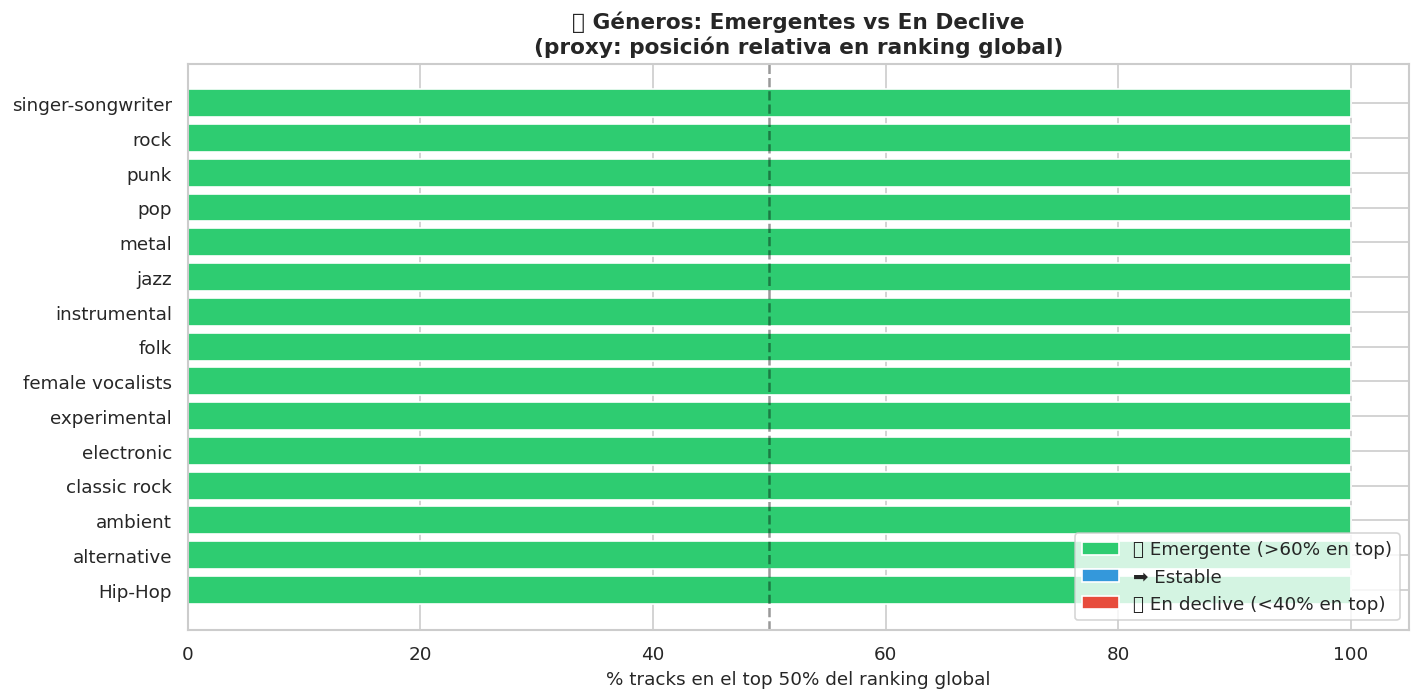


💡 Géneros emergentes: ['Hip-Hop', 'alternative', 'ambient', 'classic rock', 'electronic', 'experimental', 'female vocalists', 'folk', 'instrumental', 'jazz', 'metal', 'pop', 'punk', 'rock', 'singer-songwriter']
   Géneros en declive: []

🎯 Recomendación de negocio: apostar por Hip-Hop, alternative, ambient para maximizar visibilidad.


In [ ]:
# ── 8.3 Géneros emergentes vs en declive ──────────────────────────────────────
# Proxy: si un género tiene sus tracks concentrados en los primeros puestos
# del ranking global → está en tendencia ahora.

median_rank = df_clean['rank_global'].median()

genre_growth = (
    df_gen
    .assign(is_trending=(df_gen['rank_global'] <= median_rank).astype(int))
    .groupby('genre_tag')
    .agg(
        pct_trending=('is_trending', 'mean'),
        n_tracks    =('name', 'count'),
    )
    .query('n_tracks >= 5')  # solo géneros con masa suficiente para ser significativos
    .sort_values('pct_trending', ascending=False)
    .reset_index()
)
genre_growth['pct_trending'] *= 100
genre_growth['status'] = genre_growth['pct_trending'].apply(
    lambda x: '🚀 Emergente' if x > 60 else ('📉 En declive' if x < 40 else '➡️ Estable')
)

color_map = {'🚀 Emergente': '#2ecc71', '➡️ Estable': '#3498db', '📉 En declive': '#e74c3c'}
colors = genre_growth['status'].map(color_map)

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(genre_growth['genre_tag'], genre_growth['pct_trending'], color=colors)
ax.axvline(50, color='black', linestyle='--', alpha=0.4, label='Línea de equilibrio (50%)')
ax.set_xlabel('% tracks en el top 50% del ranking global')
ax.set_title('📊 Géneros: Emergentes vs En Declive\n(proxy: posición relativa en ranking global)',
             fontweight='bold')

from matplotlib.patches import Patch
legend_els = [Patch(facecolor='#2ecc71', label='🚀 Emergente (>60% en top)'),
              Patch(facecolor='#3498db', label='➡️ Estable'),
              Patch(facecolor='#e74c3c', label='📉 En declive (<40% en top)')]
ax.legend(handles=legend_els, loc='lower right')
plt.tight_layout()
plt.savefig('eda_generos_crecimiento.png', bbox_inches='tight')
plt.show()

emergentes = genre_growth[genre_growth['status'] == '🚀 Emergente']['genre_tag'].tolist()
en_declive = genre_growth[genre_growth['status'] == '📉 En declive']['genre_tag'].tolist()
print(f'\n💡 Géneros emergentes: {emergentes}')
print(f'   Géneros en declive: {en_declive}')
if emergentes:
    print(f'\n🎯 Recomendación de negocio: apostar por {", ".join(emergentes[:3])} para maximizar visibilidad.')

---
## 9. EDA — AcousticBrainz (subset enriquecido) <a id='acousticbrainz'></a>

⚠️ **Advertencia importante antes de interpretar esta sección:**

AcousticBrainz fue discontinuada en 2022. Su cobertura de MBIDs de Last.fm es muy baja (~1.6% en una muestra de 2.000).  
Las conclusiones de esta sección **NO se pueden generalizar** al dataset completo.

Se trabaja **solo con el subset válido** (sin NaN en las columnas AcousticBrainz).

In [ ]:
# ── 9.1 Carga del subset enriquecido ─────────────────────────────────────────
# Intentamos cargar el CSV de resultado del pipeline de enriquecimiento
ENRICHED_PATH = 'lastfm_acousticbrainz_enriched.csv'

if os.path.exists(ENRICHED_PATH):
    df_enriched_raw = pd.read_csv(ENRICHED_PATH)
    print(f'📦 Dataset enriquecido cargado: {df_enriched_raw.shape}')
    display(df_enriched_raw.head(3))

    # Columnas de AcousticBrainz que nos interesan
    ab_cols = ['bpm', 'key', 'scale', 'danceability', 'mood_happy', 'genre_ab']
    ab_cols_exist = [c for c in ab_cols if c in df_enriched_raw.columns]

    # Cobertura: ¿cuántos tracks tienen al menos un dato de AcousticBrainz?
    coverage_mask = df_enriched_raw[ab_cols_exist].notna().any(axis=1)
    n_covered = coverage_mask.sum()
    total = len(df_enriched_raw)
    print(f'\n📊 Cobertura AcousticBrainz: {n_covered:,} / {total:,} tracks ({n_covered/total*100:.1f}%)')
    print(f'\n⚠️  Causa baja cobertura: AcousticBrainz dejó de actualizarse en 2022.')
    print(f'   Los MBIDs de tracks recientes de Last.fm no tienen datos en AcousticBrainz.')

    # Trabajamos SOLO con los que tienen datos completos
    df_ab = df_enriched_raw[coverage_mask].copy()
    print(f'\n   Subset válido para análisis: {len(df_ab):,} tracks')
else:
    print(f'ℹ️  No se encontró el archivo {ENRICHED_PATH}.')
    print(f'   Para generar este archivo, ejecutar el pipeline de enriquecimiento del notebook prueba2-union-apis.ipynb.')
    print(f'   El análisis de esta sección quedará pendiente hasta entonces.')
    df_ab = None

ℹ️  No se encontró el archivo lastfm_acousticbrainz_enriched.csv.
   Para generar este archivo, ejecutar el pipeline de enriquecimiento del notebook prueba2-union-apis.ipynb.
   El análisis de esta sección quedará pendiente hasta entonces.


In [ ]:
# ── 9.2 Análisis AcousticBrainz (solo si hay datos) ──────────────────────────
if df_ab is not None and len(df_ab) > 5:

    ab_numeric = [c for c in ['bpm', 'danceability', 'mood_happy'] if c in df_ab.columns]

    if len(ab_numeric) > 0:
        fig, axes = plt.subplots(1, len(ab_numeric), figsize=(5 * len(ab_numeric), 4))
        if len(ab_numeric) == 1:
            axes = [axes]

        colors = ['steelblue', 'coral', 'seagreen']
        for ax, col, color in zip(axes, ab_numeric, colors):
            valid = df_ab[col].dropna()
            ax.hist(valid, bins=30, color=color, edgecolor='white', alpha=0.8)
            ax.set_title(f'Distribución de {col}')
            ax.set_xlabel(col)
            ax.set_ylabel('Frecuencia')
            ax.axvline(valid.median(), color='red', linestyle='--', alpha=0.7,
                       label=f'Mediana: {valid.median():.1f}')
            ax.legend(fontsize=8)

        plt.suptitle('🎧 Características de audio — AcousticBrainz (subset válido)',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig('eda_acousticbrainz_distribuciones.png', bbox_inches='tight')
        plt.show()

    # Relación BPM y Danceability con popularidad
    if 'bpm' in df_ab.columns and 'playcount' in df_ab.columns:
        df_ab_valid = df_ab[['bpm', 'danceability', 'playcount']].dropna()
        if len(df_ab_valid) > 5:
            fig, ax = plt.subplots(figsize=(8, 5))
            scatter = ax.scatter(
                df_ab_valid['bpm'],
                np.log1p(df_ab_valid['playcount']),
                c=df_ab_valid.get('danceability', 0.5),
                cmap='RdYlGn', alpha=0.7, s=40
            )
            plt.colorbar(scatter, ax=ax, label='Danceability')
            ax.set_xlabel('BPM')
            ax.set_ylabel('log(Playcount)')
            ax.set_title('BPM vs Popularidad (color = Danceability)')
            plt.tight_layout()
            plt.savefig('eda_acousticbrainz_bpm.png', bbox_inches='tight')
            plt.show()

    print(f'\n⚠️  Recordatorio: estas conclusiones aplican SOLO al subset de {len(df_ab)} tracks.')
    print(f'   No son generalizables al dataset completo de {len(df_clean):,} tracks.')
else:
    print('ℹ️  Análisis AcousticBrainz omitido — dataset enriquecido no disponible o insuficiente.')

ℹ️  Análisis AcousticBrainz omitido — dataset enriquecido no disponible o insuficiente.


---
## 10. Resumen de insights <a id='resumen'></a>

### 📋 Decisiones técnicas tomadas y justificación

| Decisión | Justificación |
|---|---|
| Eliminar `image`, `streamable`, `url` | Metadata de API sin valor analítico |
| `duration=0` → `NaN` | Last.fm devuelve 0 cuando no tiene dato de duración (no es duración real) |
| Imputar con mediana | Más robusta que media ante outliers de popularidad |
| Transformación logarítmica | Playcount y listeners tienen distribución muy sesgada (skewness > 5) |
| No eliminar outliers | Los artistas con playcount muy alto son outliers reales, no errores |
| AcousticBrainz como subset | Baja cobertura (~1.6%) → no generalizable al dataset completo |

### 🚀 Próximos pasos — Módulo ML
- Usar `playcount_log` como target de regresión
- Usar `is_hit` (percentil 75) como target de clasificación
- Features más prometedoras: `listeners_log`, `genre_encoded`, `duration_min`, `is_short_track`
- Modelos a probar: Random Forest, XGBoost, baseline Linear Regression

In [ ]:
# ── Guardar df_clean para el notebook de ML ───────────────────────────────────
df_clean.to_csv('lastfm_clean_eda.csv', index=False)
print(f'✅ df_clean guardado en lastfm_clean_eda.csv')
print(f'   Filas: {len(df_clean):,}  |  Columnas: {len(df_clean.columns)}')
print(f'   Columnas: {list(df_clean.columns)}')